<a href="https://colab.research.google.com/github/tanzeelaalvi717-blip/Protein-structure-prediction/blob/main/Copy_of_Molecular_Simmulation_Assignment03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 1) Check the runtime
import sys, platform, os, textwrap
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Working dir:", os.getcwd())

!arch

Python: 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Working dir: /content
x86_64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title Create directories `~/structbio_course/data` and `~/structbio_course/outputs`

import os
from pathlib import Path

# Change this folder name once; everything else uses it.
COURSE_DIR_NAME = "structbio_course"  # you can rename for your course

USE_DRIVE = True

if "drive" in str(Path("/content/drive")) and os.path.exists("/content/drive") and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive") / COURSE_DIR_NAME
else:
    ROOT = Path("/content") / COURSE_DIR_NAME

ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
(DATA_DIR).mkdir(exist_ok=True)

OUTPUTS_DIR = ROOT / "outputs"
(OUTPUTS_DIR).mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("Use Path object DATA_DIR to access:", DATA_DIR)
print("Use Path object OUTPUTS_DIR to access:", OUTPUTS_DIR)


ROOT: /content/drive/MyDrive/structbio_course
Use Path object DATA_DIR to access: /content/drive/MyDrive/structbio_course/data
Use Path object OUTPUTS_DIR to access: /content/drive/MyDrive/structbio_course/outputs


In [ ]:
# @title Copy over a zip archive of data files and code needed for the *gmx* exercise ... and unzip

import os, pathlib, urllib.request

RAW_URL = "https://raw.githubusercontent.com/vvoelz/chem5412-spring2026/main/data/assignment03.zip"
zip_path = pathlib.Path(DATA_DIR) / "assignment03.zip"

try:
    urllib.request.urlretrieve(RAW_URL, zip_path)
    print("Saved to:", zip_path)

    !unzip {zip_path}
    !cp -r assignment03 {DATA_DIR}
    print(f'Unzipped folder `assignment03` moved to {DATA_DIR}')
except:
    print('Failed to download and save to {zip_path}')

WORK_DIR = DATA_DIR / "assignment03"
WORK_DIR.mkdir(exist_ok=True)
print(f'WORK_DIR = {WORK_DIR}')

WORK_DIR

Saved to: /content/drive/MyDrive/structbio_course/data/assignment03.zip
Archive:  /content/drive/MyDrive/structbio_course/data/assignment03.zip
   creating: assignment03/
   creating: assignment03/mdp/
  inflating: assignment03/mdp/em.mdp  
 extracting: assignment03/mdp/minimize.mdp  
  inflating: assignment03/mdp/nvt.mdp  
  inflating: assignment03/mdp/npt.mdp  
  inflating: assignment03/1UAO_model1.pdb  
Unzipped folder `assignment03` moved to /content/drive/MyDrive/structbio_course/data
WORK_DIR = /content/drive/MyDrive/structbio_course/data/assignment03


PosixPath('/content/drive/MyDrive/structbio_course/data/assignment03')

In [ ]:
# @title Change to the working directory
%cd {WORK_DIR}

/content/drive/MyDrive/structbio_course/data/assignment03


In [ ]:
!ls

 1UAO_model1.pdb		    npt.edr	      nvt.trr
 chignolin_box.gro		    npt.gro	     '#nvt.trr.1#'
'#chignolin_box.gro.1#'		    npt.log	     '#nvt.trr.2#'
'#chignolin_box.gro.2#'		    npt_protein.gro  '#nvt.trr.3#'
'#chignolin_box.gro.3#'		    npt_protein.pdb  '#nvt.trr.4#'
 chignolin.gro			    npt_protein.xtc  '#nvt.trr.5#'
'#chignolin.gro.1#'		    npt.tpr	     '#nvt.trr.6#'
'#chignolin.gro.2#'		    npt.trr	     '#nvt.trr.7#'
'#chignolin.gro.3#'		    nvt.edr	     '#nvt.trr.8#'
 chignolin_solvated.gro		   '#nvt.edr.1#'      posre.itp
'#chignolin_solvated.gro.1#'	   '#nvt.edr.2#'     '#posre.itp.1#'
'#chignolin_solvated.gro.2#'	   '#nvt.edr.3#'     '#posre.itp.2#'
'#chignolin_solvated.gro.3#'	   '#nvt.edr.4#'     '#posre.itp.3#'
 chignolin_solvated_ions.gro	   '#nvt.edr.5#'      potential.xvg
'#chignolin_solvated_ions.gro.1#'  '#nvt.edr.6#'     '#potential.xvg.1#'
'#chignolin_solvated_ions.gro.2#'  '#nvt.edr.7#'     '#potential.xvg.2#'
 em.edr				   '#nvt.edr.8#'      pressure.xvg
'#em.edr.

In [ ]:
#@title Increase the output length
from notebook.services.config import ConfigManager
cm = ConfigManager().update('notebook', {'limit_output': 10000000})

In [ ]:
#@title Install GROMACS and related packages (~45 seconds)
!apt install gromacs &> /dev/null
!apt install dssp &> /dev/null
!ln -s /usr/bin/dssp /usr/local/bin/dssp
!apt install ghostscript &> /dev/null

In [ ]:
!which gmx

/usr/bin/gmx


In [ ]:
# @title Install py3Dmol and visualize the input PDB
!pip -q install py3Dmol

import py3Dmol

with open('1UAO_model1.pdb') as f:
    pdb = f.read()

view = py3Dmol.view(width=600, height=450)
view.addModel(pdb, "pdb")
view.setStyle({"stick": {}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# @title Use `pdb2gmx` to create a GROMACS structure (`*.gro`) and topology (`*.top`) from this structure

top_path = WORK_DIR / "topol.top"
gro_path = WORK_DIR / "chignolin.gro"

!gmx pdb2gmx -f 1UAO_model1.pdb -p topol.top -o chignolin.gro -ff amber99sb-ildn -ignh -heavyh -water tip3p

             :-) GROMACS - gmx pdb2gmx, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# @title Let's inspect the head and tail of the `chignolin.gro` file...

!head chignolin.gro
!echo "..."
!tail chignolin.gro

Good ROcking Metal Altar for Chronical Sinners
  138
    1GLY      N    1  -0.678  -0.142   0.420
    1GLY     H1    2  -0.764  -0.134   0.470
    1GLY     H2    3  -0.658  -0.239   0.404
    1GLY     H3    4  -0.604  -0.102   0.474
    1GLY     CA    5  -0.688  -0.071   0.290
    1GLY    HA1    6  -0.708   0.026   0.307
    1GLY    HA2    7  -0.762  -0.111   0.236
    1GLY      C    8  -0.556  -0.084   0.214
...
    9TRP      O  130  -0.158  -0.553   0.242
   10GLY      N  131  -0.184  -0.346   0.311
   10GLY      H  132  -0.217  -0.253   0.292
   10GLY     CA  133  -0.123  -0.377   0.443
   10GLY    HA1  134  -0.137  -0.300   0.505
   10GLY    HA2  135  -0.025  -0.392   0.431
   10GLY      C  136  -0.188  -0.503   0.501
   10GLY    OC1  137  -0.295  -0.491   0.558
   10GLY    OC2  138  -0.129  -0.609   0.488
   1.39835   1.24466   1.06869


In [ ]:
with open('chignolin.gro') as f:
    gro = f.read()

# parse box from last line
box = list(map(float, gro.splitlines()[-1].split()))
Lx, Ly, Lz = [10*x for x in box[:3]]  # convert nm → Å

view = py3Dmol.view(width=600, height=450)

view.addModel(gro, "gro")
view.setStyle({"stick": {}})
view.zoomTo()

def add_pbc_box(view, Lx, Ly, Lz, color="black", radius=0.30):

    corners = [
        (0,0,0), (Lx,0,0), (Lx,Ly,0), (0,Ly,0),
        (0,0,Lz), (Lx,0,Lz), (Lx,Ly,Lz), (0,Ly,Lz)
    ]

    edges = [
        (0,1),(1,2),(2,3),(3,0),   # bottom
        (4,5),(5,6),(6,7),(7,4),   # top
        (0,4),(1,5),(2,6),(3,7)    # verticals
    ]

    for i,j in edges:
        view.addLine({
            "start": {"x": corners[i][0], "y": corners[i][1], "z": corners[i][2]},
            "end":   {"x": corners[j][0], "y": corners[j][1], "z": corners[j][2]},
            "color": color,
            "radius": radius
        })

view.addBox({
    "center": {"x": Lx/2, "y": Ly/2, "z": Lz/2},
    "dimensions": {"w": Lx, "h": Ly, "d": Lz},
    "color": "red",
    "opacity": 0.3
})

add_pbc_box(view, Lx, Ly, Lz)

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
!gmx editconf -f chignolin.gro -bt cubic -d 1.0 -o chignolin_box.gro

             :-) GROMACS - gmx editconf, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff           

In [ ]:
!gmx solvate -cp chignolin_box.gro -p topol.top -o chignolin_solvated.gro

             :-) GROMACS - gmx solvate, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# @title First we generate a temporary run input file:
!gmx grompp -f mdp/em.mdp -c chignolin_solvated.gro -r chignolin_solvated.gro -p topol.top -o em.tpr -v -maxwarn 2

# @markdown ... Then we replace some water molecules with ions.
# @markdown IMPORTANT: When prompted, choose the `SOL` group so that ions replace water molecules.

!gmx genion -s em.tpr -p topol.top -o chignolin_solvated_ions.gro -conc 0.100 -neutral

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
! gmx grompp -f mdp/em.mdp -c chignolin_solvated_ions.gro -r chignolin_solvated_ions.gro -p topol.top -o em.tpr -v -maxwarn 2
! gmx mdrun -v -s em.tpr -c em.gro -e em.edr

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# @title Plot the potential energy vs. minimization step
!echo "10\n" | gmx energy -f em.edr -o potential.xvg


              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

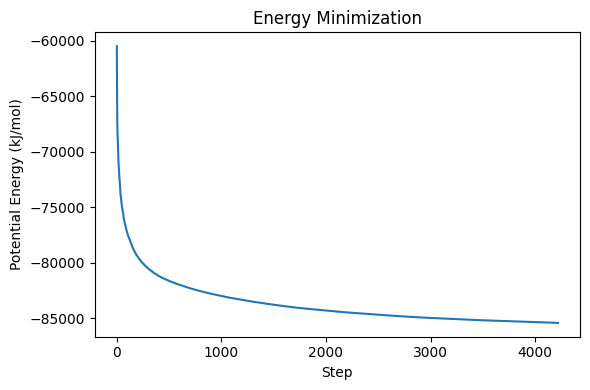

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def read_xvg(file):
    data = []
    with open(file) as f:
        for line in f:
            if line.startswith(('#','@')):
                continue
            data.append([float(x) for x in line.split()])
    return np.array(data)

pot = read_xvg("potential.xvg")

plt.figure( figsize=(6,4) )

plt.plot(pot[:,0], pot[:,1])
plt.xlabel("Step")
plt.ylabel("Potential Energy (kJ/mol)")
plt.title("Energy Minimization")

plt.tight_layout()
plt.show()

# @markdown NOTE: to save as PDF, uncomment:
# @markdown ```
# @markdown outfile = 'energy_minimization.pdf'
# @markdown plt.savefig(outfile)
# @markdown print('Wrote:', outfile)
# @markdown ```

In [ ]:
# @title Perform the NVT simulation (~ 28 min)
!gmx grompp -f mdp/nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr -v -maxwarn 2
!gmx mdrun -v -s nvt.tpr -c nvt.gro -g nvt.log -e nvt.edr -o nvt.trr


              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# @title Perform the NPT simulation (~ 28 min)
!gmx grompp -f mdp/npt.mdp -c nvt.gro -r nvt.gro -p topol.top -o npt.tpr -v -maxwarn 2
!gmx mdrun -v -s npt.tpr -c npt.gro -g npt.log -e npt.edr -o npt.trr

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# @title Plot the potential energy vs. minimization step
!echo "17\n" | gmx energy -f npt.edr -o pressure.xvg
!echo "22\n" | gmx energy -f npt.edr -o volume.xvg

              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

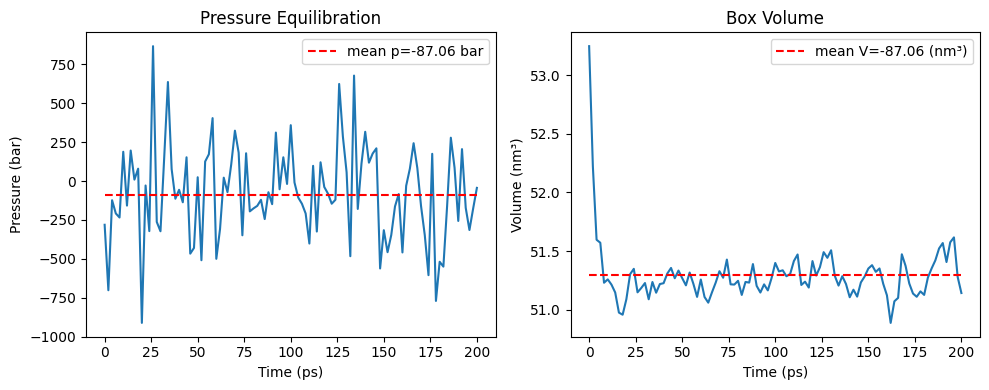

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def read_xvg(file):
    data = []
    with open(file) as f:
        for line in f:
            if line.startswith(('#','@')):
                continue
            data.append([float(x) for x in line.split()])
    return np.array(data)

pressure = read_xvg("pressure.xvg")
volume = read_xvg("volume.xvg")

n =  pressure.shape[0]
n_half = int(n/2)
# calculate mean pressure from 2nd half of the trace
mean_p = np.mean(pressure[n_half:,1])
mean_pressure = mean_p*np.ones(pressure[:,1].shape)

# calculate mean volume from 2nd half of the trace
mean_V = np.mean(volume[n_half:,1])
mean_volume = mean_V*np.ones(volume[:,1].shape)


fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(pressure[:,0], pressure[:,1])
ax[0].plot(pressure[:,0], mean_pressure, 'r--', label=f'mean p={mean_p:.4g} bar')
ax[0].set_xlabel("Time (ps)")
ax[0].set_ylabel("Pressure (bar)")
ax[0].set_title("Pressure Equilibration")
ax[0].legend(loc='best')

ax[1].plot(volume[:,0], volume[:,1])
ax[1].plot(volume[:,0], mean_volume, 'r--', label=f'mean V={mean_p:.4g} (nm³)')
ax[1].set_xlabel("Time (ps)")
ax[1].set_ylabel("Volume (nm³)")
ax[1].set_title("Box Volume")
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()

# @markdown NOTE: to save as PDF, uncomment:
# @markdown ```
# @markdown outfile = 'pressure_volume_equil.pdf'
# @markdown plt.savefig(outfile)
# @markdown print('Wrote:', outfile)
# @markdown ```



In [ ]:
# @title Create an index file
!echo "q\n" | gmx make_ndx -f npt.gro -o index.ndx

             :-) GROMACS - gmx make_ndx, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff           

In [ ]:
# @title MAke a protein-only trajectory
!echo "1\n" | gmx trjconv -f npt.trr -s npt.tpr -n index.ndx -o npt_protein.xtc

             :-) GROMACS - gmx trjconv, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
print('--- Tail of chignolin_solvated_ions.gro ---')
!tail chignolin_solvated_ions.gro

--- Tail of chignolin_solvated_ions.gro ---
 1659SOL    HW2 5085   2.821   3.768   2.066
 1660NA      NA 5086   0.768   1.144   2.885
 1661NA      NA 5087   1.466   0.590   2.854
 1662NA      NA 5088   1.759   3.609   1.154
 1663NA      NA 5089   2.853   0.410   1.242
 1664NA      NA 5090   3.500   1.099   2.941
 1665CL      CL 5091   1.076   2.545   1.464
 1666CL      CL 5092   3.719   0.833   2.239
 1667CL      CL 5093   2.863   1.896   1.154
   3.76214   3.76214   3.76214


In [ ]:
# Extract box dimensions from the last line of the .gro file
with open('chignolin_solvated_ions.gro', 'r') as f:
    gro_lines = f.readlines()
last_line = gro_lines[-1].strip()
box_dims_str = last_line.split()

# Convert to float and assign L1, L2, L3
L1, L2, L3 = [float(dim) for dim in box_dims_str]

# Number of Na+ ions (from previous analysis)
num_na_ions = 5  # From 'topol.top' analysis

# Avogadro's number
NA = 6.022e23 # mol^-1

# Convert number of Na+ ions to moles
moles_na = num_na_ions / NA

# Calculate volume in nm^3
volume_nm3 = L1 * L2 * L3

# Convert volume from nm^3 to liters
# 1 nm^3 = 10^-27 m^3
# 1 L = 0.001 m^3 = 10^-3 m^3
# So, 1 L = 10^24 nm^3
volume_L = volume_nm3 * (1e-27 / 1e-3) # volume_nm3 * (m^3 / nm^3) * (L / m^3)

# Calculate concentration in M (mol/L)
concentration_M = moles_na / volume_L

print(f"Box dimensions: L1={L1:.3f} nm, L2={L2:.3f} nm, L3={L3:.3f} nm")
print(f"Number of Na+ ions: {num_na_ions}")
print(f"Volume of the box: {volume_nm3:.3f} nm^3")
print(f"Volume of the box: {volume_L:.6f} L")
print(f"Concentration of Na+ ions: {concentration_M:.4f} M")

desired_concentration_M = 0.1
if abs(concentration_M - desired_concentration_M) < 0.01: # Check if it's close enough
    print(f"The calculated concentration ({concentration_M:.4f} M) is close to the desired concentration of {desired_concentration_M} M.")
else:
    print(f"The calculated concentration ({concentration_M:.4f} M) is NOT close to the desired concentration of {desired_concentration_M} M.")

Box dimensions: L1=3.762 nm, L2=3.762 nm, L3=3.762 nm
Number of Na+ ions: 5
Volume of the box: 53.248 nm^3
Volume of the box: 0.000000 L
Concentration of Na+ ions: 0.1559 M
The calculated concentration (0.1559 M) is NOT close to the desired concentration of 0.1 M.


In [ ]:
print('--- Tail of topol.top ---')
!tail topol.top

--- Tail of topol.top ---
[ system ]
; Name
Protein in water

[ molecules ]
; Compound        #mols
Protein_chain_A     1
SOL         1649
NA               5
CL               3


In [ ]:
# @title Make a protein-only `*.gro` file
!echo "1\n" | gmx trjconv -f npt.gro -s npt.tpr -n index.ndx -o npt_protein.gro

             :-) GROMACS - gmx trjconv, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# @title Load the trajectory
import mdtraj as md

traj = md.load("npt_protein.xtc", top="npt_protein.gro")
print(traj)
traj.save_pdb('npt_protein.pdb')

<mdtraj.Trajectory with 101 frames, 138 atoms, 10 residues, and unitcells>


In [ ]:
# @title Visualize trajectory using py3Dmol
import py3Dmol

with open('npt_protein.pdb') as f:
    pdb = f.read()

view = py3Dmol.view(width=600, height=450)
view.addModelsAsFrames(pdb)

view.setStyle({'cartoon': {'color':'spectrum'}})
view.zoomTo()

view.animate({'loop':'forward'})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# @title Optional: Show atoms explicitly
import py3Dmol

with open('npt_protein.pdb') as f:
    pdb = f.read()

view = py3Dmol.view(width=600, height=450)
view.addModelsAsFrames(pdb)

view.setStyle({'stick':{}})
view.zoomTo()

view.animate({'loop':'forward'})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.